<a href="https://colab.research.google.com/github/abergh18/marl-tsc/blob/zak_new/graph_testing_flow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### env

In [1]:
import sys

IN_COLAB = 'google.colab' in sys.modules
COLAB = False

if IN_COLAB:
    print("Running inside Google Colab!")
    COLAB = True
else:
    print("Running in a local/different environment.")

Running inside Google Colab!


In [2]:
if not COLAB:
  # Uncomment these in a fresh notebook environment.
  %pip install -r ../requirements.txt
  %pip install -e ..

In [3]:
if COLAB:
  #GITHUB --> COLAB CLONE / env setup
  import os
  from google.colab import userdata

  # 1. Get your access token
  token = userdata.get('GH_TOKEN')

  # 2. Clone the repo if it's not already there
  repo_path = '/content/marl-tsc'
  if not os.path.exists(repo_path):
      !git clone --branch zak_new --single-branch https://{token}@github.com/abergh18/marl-tsc.git

  # 3. CRUCIAL: Move to the root directory
  # This ensures that 'import models' or 'import utils' works correctly
  %cd {repo_path}

  # 4. Install dependencies
  !pip install -r requirements.txt

/content/marl-tsc
  Using cached traci-1.26.0-py2.py3-none-any.whl.metadata (3.2 kB)
  Using cached sumolib-1.26.0-py2.py3-none-any.whl.metadata (2.6 kB)
Using cached traci-1.26.0-py2.py3-none-any.whl (138 kB)
Using cached sumolib-1.26.0-py2.py3-none-any.whl (233 kB)
  Attempting uninstall: sumolib
    Found existing installation: sumolib 1.27.1
    Uninstalling sumolib-1.27.1:
      Successfully uninstalled sumolib-1.27.1
  Attempting uninstall: traci
    Found existing installation: traci 1.27.1
    Uninstalling traci-1.27.1:
      Successfully uninstalled traci-1.27.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
libsumo 1.27.1 requires traci>=1.27.1, but you have traci 1.26.0 which is incompatible.


In [4]:
if COLAB:
  !pip install eclipse-sumo libsumo

  import os
  os.environ["SUMO_HOME"] = "/usr/local/lib/python3.12/dist-packages/sumo"
  os.environ["PATH"] += ":/usr/local/lib/python3.12/dist-packages/sumo/bin"

  Using cached traci-1.27.1-py2.py3-none-any.whl.metadata (3.2 kB)
  Using cached sumolib-1.27.1-py2.py3-none-any.whl.metadata (2.8 kB)
Using cached traci-1.27.1-py2.py3-none-any.whl (138 kB)
Using cached sumolib-1.27.1-py2.py3-none-any.whl (236 kB)
  Attempting uninstall: sumolib
    Found existing installation: sumolib 1.26.0
    Uninstalling sumolib-1.26.0:
      Successfully uninstalled sumolib-1.26.0
  Attempting uninstall: traci
    Found existing installation: traci 1.26.0
    Uninstalling traci-1.26.0:
      Successfully uninstalled traci-1.26.0


In [5]:
from pathlib import Path
import sys
#Had to remove '.parent' for colab specific version
PROJECT_ROOT = Path.cwd().resolve()
SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

In [6]:
from pathlib import Path

import matplotlib.pyplot as plt

GREEN_PHASE_COUNT = None

def print_comparison_table(rows):
    columns = [
        "Policy",
        "Episodes",
        "Mean total reward",
        "Mean local queue",
        "Total completed steps",
        "Mean switches / episode",
    ]

    def format_value(value):
        if isinstance(value, float):
            return f"{value:.3f}"
        return str(value)

    widths = {column: len(column) for column in columns}
    for row in rows:
        for column in columns:
            widths[column] = max(widths[column], len(format_value(row.get(column, ""))))

    header = " | ".join(column.ljust(widths[column]) for column in columns)
    separator = "-+-".join("-" * widths[column] for column in columns)
    print(header)
    print(separator)
    for row in rows:
        print(" | ".join(format_value(row.get(column, "")).ljust(widths[column]) for column in columns))


In [7]:
from marl_tsc.simulation_generator import SimulationGenerator, DEFAULT_TRAFFIC_LIGHT_IDS
from marl_tsc.training import train_ppo, evaluate_policy, plot_training_histories
from marl_tsc.mappo import train_mappo
from marl_tsc.baselines import random_actions, fixed_time_actions

NOTEBOOK_DIR = Path.cwd().resolve()
PROJECT_ROOT = NOTEBOOK_DIR.parent if (NOTEBOOK_DIR / "main_flow.ipynb").exists() else NOTEBOOK_DIR
if COLAB:
  from google.colab import drive
  drive.mount('/content/drive')
  OUTPUT_DIR = '/content/drive/MyDrive/Uni-Masters/Group Project/outputs'
else:
  OUTPUT_DIR = PROJECT_ROOT / "outputs"

traffic_light_ids = list(DEFAULT_TRAFFIC_LIGHT_IDS)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
#! ls -la '/content/drive/MyDrive/Uni-Masters/Group Project/outputs'

In [9]:
EPISODE_STEPS = 600
SECONDS_PER_ACTION = 5
SIMULATION_DURATION = EPISODE_STEPS * SECONDS_PER_ACTION

# Keep vehicles entering slightly longer than the episode runs.
TRAFFIC_SPAWN_DURATION = int(SIMULATION_DURATION * 1.20)

EVALUATION_EPISODES = 3
TOTAL_TIMESTEPS = 200_000
MIN_GREEN_SECONDS = 10
SWITCH_PENALTY = 0.00

generator = SimulationGenerator(
    output_dir=OUTPUT_DIR,
    grid_number=4,
    lane_number=2,
    traffic_light_ids=traffic_light_ids,
    trip_begin=0,
    trip_end=TRAFFIC_SPAWN_DURATION,
    trip_period=2,
    seed=42,
)

paths = generator.generate_all()
print(f"Generated SUMO config: {paths.config_file}")
print(f"Simulation horizon: {SIMULATION_DURATION}s")
print(f"Traffic spawn duration: {TRAFFIC_SPAWN_DURATION}s")
print("Traffic-light agents:", traffic_light_ids)

Generated SUMO config: /content/drive/MyDrive/Uni-Masters/Group Project/outputs/config.sumocfg
Simulation horizon: 3000s
Traffic spawn duration: 3600s
Traffic-light agents: ['B1', 'B2', 'C1', 'C2']


## 2. Run the simple baselines

Random and fixed-time are useful sanity checks before training. They use the same environment and the same evaluation seeds as the learned policies.


In [ ]:
# ==========================================
# 1. RANDOM BASELINE EVALUATION
# ==========================================
random_result = evaluate_policy(
    config_file=paths.config_file,
    traffic_light_ids=traffic_light_ids,             # Match MAPPO: TODO:Extract dynamically from the net file
    policy=random_actions,
    episodes=1,#EVALUATION_EPISODES,       # Use 10 episodes to match MAPPO evaluation
    max_steps=600, #EPISODE_STEPS,            # FIX: Must be 600 steps, not 3000 duration
    seed=42,
    env_kwargs={
        "green_phase_count": 4,
        "min_green_seconds": MIN_GREEN_SECONDS,
        "seconds_per_action": SECONDS_PER_ACTION,
        #"max_steps": 600,     # Pass to ensure internal alignment
    },
)

# ==========================================
# 2. FIXED-TIME BASELINE EVALUATION
# ==========================================
fixed_time_result = evaluate_policy(
    config_file=paths.config_file,
    traffic_light_ids=traffic_light_ids,             # Match MAPPO: TODO: Extract dynamically from the net file
    policy=fixed_time_actions,
    episodes= 1,#EVALUATION_EPISODES,       # Use 10 episodes to match MAPPO evaluation
    max_steps= 600, #EPISODE_STEPS,            # FIX: Must be 600 steps, not 3000 duration
    seed=42,
    env_kwargs={
        "green_phase_count": 4,
        "min_green_seconds": MIN_GREEN_SECONDS,
        "seconds_per_action": SECONDS_PER_ACTION,
        #"max_steps": 600,     # Pass to ensure internal alignment
    },
)

 Retrying in 1 seconds
Step #0.00 (0ms ?*RT. ?UPS, TraCI: 2ms, vehicles TOT 0 ACT 0 BUF 0)                      
 Retrying in 1 seconds
Step #3000.00 (0ms ?*RT. ?UPS, TraCI: 7ms, vehicles TOT 1500 ACT 39 BUF 0)                
Finished Evaluation Episode 1/1 - Total Reward: -133.12
 Retrying in 1 seconds
Step #0.00 (0ms ?*RT. ?UPS, TraCI: 2ms, vehicles TOT 0 ACT 0 BUF 0)                      
 Retrying in 1 seconds
Step #3000.00 (3ms ~= 333.33*RT, ~184000.00UPS, TraCI: 8ms, vehicles TOT 1160 ACT 552 BUF 
Finished Evaluation Episode 1/1 - Total Reward: -1335.24


In [ ]:
baseline_rows = [
    {
        "Policy": "Random",
        "Episodes": random_result["episodes"],
        "Mean total reward": random_result["mean_total_reward"],
        "Mean local queue": random_result["mean_local_queue"],
        "Total completed steps": random_result["total_completed_steps"],
        "Mean switches / episode": random_result["mean_switches_per_episode"],
    },
    {
        "Policy": "Fixed-Time",
        "Episodes": fixed_time_result["episodes"],
        "Mean total reward": fixed_time_result["mean_total_reward"],
        "Mean local queue": fixed_time_result["mean_local_queue"],
        "Total completed steps": fixed_time_result["total_completed_steps"],
        "Mean switches / episode": fixed_time_result["mean_switches_per_episode"],
    },
]
print_comparison_table(baseline_rows)

Policy     | Episodes | Mean total reward | Mean local queue | Total completed steps | Mean switches / episode
-----------+----------+-------------------+------------------+-----------------------+------------------------
Random     | 1        | -133.120          | 0.512            | 600                   | 1027.000               
Fixed-Time | 1        | -1335.235         | 5.514            | 600                   | 1196.000               


## Traci Escape Hatch

In [28]:
on = True
if on:
    # Stop Traci processes if not already stopped, to prevent connection issues in subsequent runs
    import sys

    # 1. Force clear TraCI's internal connection registries
    try:
        import traci
        traci.switch("default")
        traci.close()
    except Exception:
        pass

    try:
        # Completely purge the connection dictionary tracking connections
        import traci.main
        traci.main._connections.clear()
        print("Purged TraCI connections dictionary.")
    except Exception:
        pass

    # 2. Reset the module completely out of Python sys memory
    if 'traci' in sys.modules:
        del sys.modules['traci']
        print("Flushed TraCI module from Python runtime memory.")

    # 3. Re-import fresh
    import traci
    print("TraCI state successfully reset!")

Flushed TraCI module from Python runtime memory.
TraCI state successfully reset!


## Graph Stuff


In [10]:
#paths = generator_graphs.generate_all()
paths = generator.generate_all()

### viz

In [10]:
from marl_tsc.graph_based.graph_builder import GraphBuilder

builder = GraphBuilder(paths.network_file)

topology = builder.build()
print("Topology output:")
print("List of Nodes")
print(topology.agent_ids)
print("Edge Index:Columns Represent source --> Target")
print(topology.edge_index)

Topology output:
List of Nodes
['B1', 'B2', 'C1', 'C2']
Edge Index:Columns Represent source --> Target
tensor([[0, 3, 2, 2, 0, 1, 3, 1],
        [1, 1, 0, 3, 2, 0, 2, 3]])


In [11]:
tls = next(iter(builder.net.getTrafficLights()))

connections = tls.getConnections()

print(connections[0])

incoming_lane = connections[0][0]
outgoing_lane = connections[0][1]

print(type(incoming_lane))
print(type(outgoing_lane))

print(sorted(
    attr
    for attr in dir(incoming_lane)
    if not attr.startswith("_")
)[:50])

[<sumolib.net.lane.Lane object at 0x7f3e2e30a3c0>, <sumolib.net.lane.Lane object at 0x7f3e2e3091c0>, 15]
<class 'sumolib.net.lane.Lane'>
<class 'sumolib.net.lane.Lane'>
['addOutgoing', 'allows', 'getBoundingBox', 'getClosestLanePosAndDist', 'getConnection', 'getEdge', 'getID', 'getIncoming', 'getIncomingConnections', 'getIndex', 'getLength', 'getNeigh', 'getOutgoing', 'getOutgoingEdges', 'getOutgoingLanes', 'getParam', 'getParams', 'getPermissions', 'getShape', 'getShape3D', 'getSpeed', 'getWidth', 'interpretOffset', 'isAccelerationLane', 'isNormal', 'setNeigh', 'setParam', 'setPermissions', 'setShape']


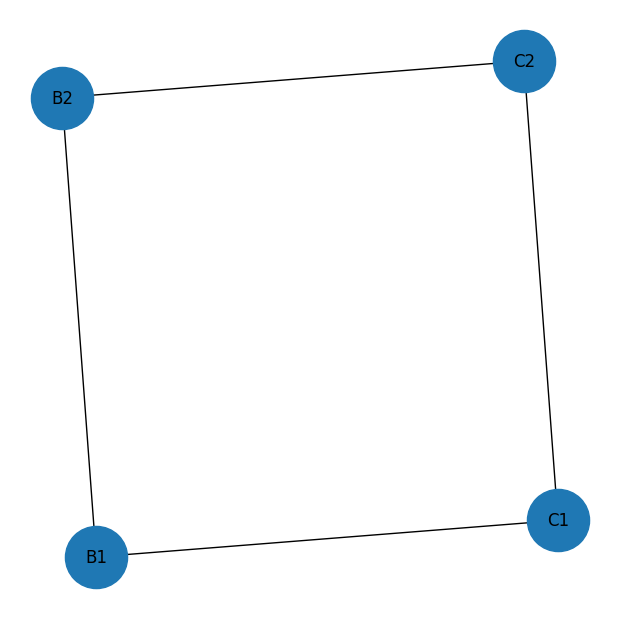

In [12]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.Graph()

for agent in topology.agent_ids:
    G.add_node(agent)

for src, dst in topology.edge_index.t().tolist():
    G.add_edge(
        topology.agent_ids[src],
        topology.agent_ids[dst]
    )

plt.figure(figsize=(6, 6))

nx.draw(
    G,
    with_labels=True,
    node_size=2000,
)

plt.show()

### Graph ctde

In [13]:
from marl_tsc.graph_based.train_graph_ctde import (
    train_graph_ctde,
)

model, history, model_path = (
    train_graph_ctde(
        config_file=paths.config_file,
        network_file=paths.network_file,
        traffic_light_ids=traffic_light_ids,
        output_dir=OUTPUT_DIR,
        total_timesteps=20_000,
        rollout_steps=256,
        actor_learning_rate=2e-4,
        critic_learning_rate=5e-4,
        entropy_coef=5e-3,
        env_kwargs={
            "green_phase_count": GREEN_PHASE_COUNT,
            "min_green_seconds": MIN_GREEN_SECONDS,
            "seconds_per_action": SECONDS_PER_ACTION,
            "switch_penalty": SWITCH_PENALTY,
            "global_metric_interval": 10,
        },
    )
)

print(type(model))
print(len(history))
print(model_path)
print(history[-1])

Streaming output truncated to the last 5000 lines.
value=-7.829 target=-7.986
entropy=5.5420 | logit_gap=0.1014 | max_prob=0.2593
value=-7.779 target=-7.973
entropy=5.5424 | logit_gap=0.0992 | max_prob=0.2592
value=-7.847 target=-7.934
entropy=5.5418 | logit_gap=0.1041 | max_prob=0.2588
value=-7.711 target=-7.921
entropy=5.5425 | logit_gap=0.0989 | max_prob=0.2596
value=-7.804 target=-7.905
entropy=5.5420 | logit_gap=0.1086 | max_prob=0.2605
value=-7.824 target=-7.914
entropy=5.5426 | logit_gap=0.0971 | max_prob=0.2592
value=-7.764 target=-7.905
entropy=5.5419 | logit_gap=0.1042 | max_prob=0.2586
value=-7.772 target=-7.884
entropy=5.5415 | logit_gap=0.1101 | max_prob=0.2589
value=-7.813 target=-7.906
entropy=5.5425 | logit_gap=0.0977 | max_prob=0.2590
value=-7.803 target=-7.921
entropy=5.5418 | logit_gap=0.1084 | max_prob=0.2595
value=-7.761 target=-7.926
entropy=5.5425 | logit_gap=0.0982 | max_prob=0.2594
value=-7.736 target=-7.943
entropy=5.5419 | logit_gap=0.1033 | max_prob=0.2587
v

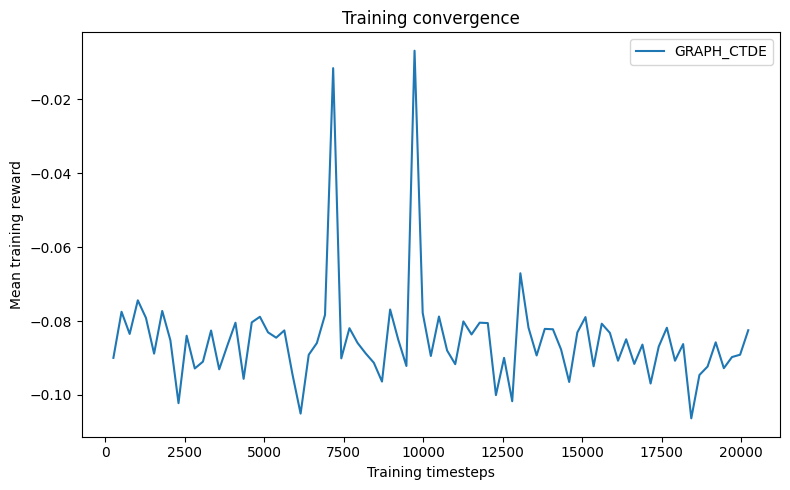

In [14]:
fig, ax = plot_training_histories(history)
plt.show()

In [ ]:
#history

In [12]:
import matplotlib.pyplot as plt
import numpy as np


def plot_training_history(history):

    actor_loss = [
        h["actor_loss"]
        for h in history
    ]

    critic_loss = [
        h["critic_loss"]
        for h in history
    ]

    total_loss = [
        h["total_loss"]
        for h in history
    ]

    reward = [
        h["mean_training_reward"]
        for h in history
    ]

    x = np.arange(len(history))

    fig, axes = plt.subplots(
        2,
        2,
        figsize=(14, 8),
    )

    #
    # Actor
    #

    axes[0, 0].plot(
        x,
        actor_loss,
    )
    axes[0, 0].set_title(
        "Actor Loss"
    )
    axes[0, 0].grid(True)

    #
    # Critic
    #

    axes[0, 1].plot(
        x,
        critic_loss,
    )
    axes[0, 1].set_title(
        "Critic Loss"
    )
    axes[0, 1].grid(True)

    #
    # Reward
    #

    axes[1, 0].plot(
        x,
        reward,
    )

    if len(reward) >= 10:

        rolling = np.convolve(
            reward,
            np.ones(10) / 10,
            mode="valid",
        )

        axes[1, 0].plot(
            np.arange(
                9,
                len(reward),
            ),
            rolling,
            linewidth=2,
        )

    axes[1, 0].set_title(
        "Mean Training Reward"
    )
    axes[1, 0].grid(True)

    #
    # Critic vs Actor
    #

    axes[1, 1].plot(
        x,
        critic_loss,
        label="critic",
    )

    axes[1, 1].plot(
        x,
        np.abs(actor_loss),
        label="|actor|",
    )

    axes[1, 1].set_title(
        "Loss Magnitude Comparison"
    )

    axes[1, 1].legend()
    axes[1, 1].grid(True)

    plt.tight_layout()
    plt.show()

    #
    # Useful summary stats
    #

    print(
        f"Final Actor Loss : {actor_loss[-1]:.6f}"
    )

    print(
        f"Final Critic Loss: {critic_loss[-1]:.6f}"
    )

    print(
        f"Best Critic Loss : {min(critic_loss):.6f}"
    )

    print(
        f"Mean Reward      : {np.mean(reward):.6f}"
    )

    print(
        f"Final Reward     : {reward[-1]:.6f}"
    )

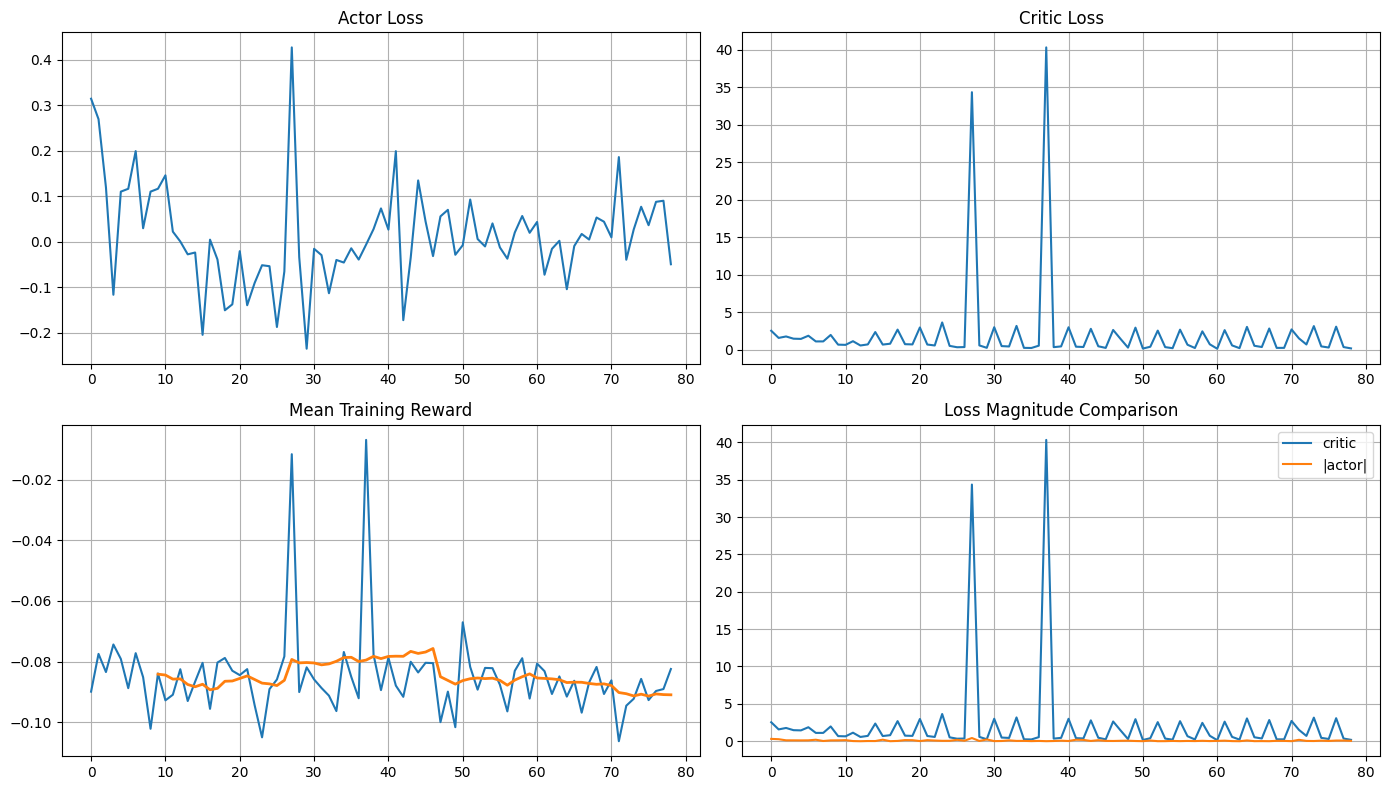

Final Actor Loss : -0.049673
Final Critic Loss: 0.183842
Best Critic Loss : 0.140255
Mean Reward      : -0.084916
Final Reward     : -0.082471


In [16]:
plot_training_history(history)

In [17]:
def get_evaluation_results(policy):
    return evaluate_policy(
        config_file=paths.config_file,
        traffic_light_ids=traffic_light_ids,
        policy=policy,
        episodes=EVALUATION_EPISODES,
        max_steps=EPISODE_STEPS,
        seed=42,
        env_kwargs={
            "green_phase_count": GREEN_PHASE_COUNT,
            "min_green_seconds": MIN_GREEN_SECONDS,
            "seconds_per_action": SECONDS_PER_ACTION,
            "switch_penalty": SWITCH_PENALTY,
            "global_metric_interval": 10,
        },
    )

In [18]:
from marl_tsc.graph_based.graph_policy_adapter import (
    GraphPolicyAdapter,
)

graph_policy = GraphPolicyAdapter(
    graph_policy=model,
    topology=topology,
    policy_name="graph_ctde",
)

results = get_evaluation_results(
    graph_policy
)

print(results)

 Retrying in 1 seconds
 Retrying in 1 seconds


/content/marl-tsc/src/marl_tsc/graph_based/graph_policy_adapter.py:31: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  x = torch.tensor(


Actions: {'B1': 3, 'B2': 3, 'C1': 3, 'C2': 3}
Actions: {'B1': 3, 'B2': 3, 'C1': 3, 'C2': 3}
Actions: {'B1': 1, 'B2': 1, 'C1': 1, 'C2': 1}
Actions: {'B1': 3, 'B2': 3, 'C1': 3, 'C2': 3}
Actions: {'B1': 2, 'B2': 2, 'C1': 2, 'C2': 2}
Actions: {'B1': 2, 'B2': 2, 'C1': 2, 'C2': 2}
Actions: {'B1': 2, 'B2': 2, 'C1': 2, 'C2': 2}
Actions: {'B1': 2, 'B2': 2, 'C1': 2, 'C2': 2}
Actions: {'B1': 2, 'B2': 2, 'C1': 2, 'C2': 2}
Actions: {'B1': 2, 'B2': 2, 'C1': 2, 'C2': 2}
Actions: {'B1': 2, 'B2': 2, 'C1': 2, 'C2': 2}
Actions: {'B1': 2, 'B2': 2, 'C1': 2, 'C2': 2}
Actions: {'B1': 2, 'B2': 2, 'C1': 2, 'C2': 2}
Actions: {'B1': 2, 'B2': 2, 'C1': 2, 'C2': 2}
Actions: {'B1': 2, 'B2': 2, 'C1': 2, 'C2': 2}
Actions: {'B1': 2, 'B2': 2, 'C1': 2, 'C2': 2}
Actions: {'B1': 2, 'B2': 2, 'C1': 2, 'C2': 2}
Actions: {'B1': 2, 'B2': 2, 'C1': 2, 'C2': 2}
Actions: {'B1': 2, 'B2': 2, 'C1': 2, 'C2': 2}
Actions: {'B1': 2, 'B2': 2, 'C1': 2, 'C2': 2}
Actions: {'B1': 2, 'B2': 2, 'C1': 2, 'C2': 2}
Actions: {'B1': 2, 'B2': 2, 'C1': 

In [ ]:
from pprint import pprint
from marl_tsc.graph_based.graph_policy_adapter import GraphPolicyAdapter

results = get_evaluation_results(
    GraphPolicyAdapter(model,topology)
)

pprint(results)

 Retrying in 1 seconds
 Retrying in 1 seconds
Actions: {'B1': 2, 'B2': 2, 'C1': 2, 'C2': 2}
Actions: {'B1': 2, 'B2': 2, 'C1': 2, 'C2': 2}
Actions: {'B1': 3, 'B2': 3, 'C1': 3, 'C2': 3}
Actions: {'B1': 0, 'B2': 0, 'C1': 0, 'C2': 0}
Actions: {'B1': 2, 'B2': 2, 'C1': 2, 'C2': 2}
Actions: {'B1': 0, 'B2': 0, 'C1': 0, 'C2': 0}
Actions: {'B1': 3, 'B2': 3, 'C1': 3, 'C2': 3}
Actions: {'B1': 0, 'B2': 0, 'C1': 0, 'C2': 0}
Actions: {'B1': 2, 'B2': 2, 'C1': 2, 'C2': 2}
Actions: {'B1': 0, 'B2': 0, 'C1': 0, 'C2': 0}
Actions: {'B1': 3, 'B2': 3, 'C1': 3, 'C2': 3}
Actions: {'B1': 0, 'B2': 0, 'C1': 0, 'C2': 0}
Actions: {'B1': 2, 'B2': 2, 'C1': 2, 'C2': 2}
Actions: {'B1': 0, 'B2': 0, 'C1': 0, 'C2': 0}
Actions: {'B1': 3, 'B2': 3, 'C1': 3, 'C2': 3}
Actions: {'B1': 0, 'B2': 0, 'C1': 0, 'C2': 0}
Actions: {'B1': 2, 'B2': 2, 'C1': 2, 'C2': 2}
Actions: {'B1': 0, 'B2': 0, 'C1': 0, 'C2': 0}
Actions: {'B1': 3, 'B2': 3, 'C1': 3, 'C2': 3}
Actions: {'B1': 0, 'B2': 0, 'C1': 0, 'C2': 0}
Actions: {'B1': 2, 'B2': 2, 'C1': 

### Graph-mappo

In [10]:
from marl_tsc.graph_based.train_graph_mappo import train_graph_mappo

map_gat_model, map_gat_history, map_cat_model_path = train_graph_mappo(
    config_file=paths.config_file,
    network_file=paths.network_file,
    traffic_light_ids=["B1", "B2", "C1", "C2"],
    output_dir=OUTPUT_DIR,
    total_timesteps=20_000,
    clip_ratio=0.2,
    entropy_coef=0.01,
    update_epochs=3,
)

 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
Iter  10 | Actor 0.0841 | Critic 0.6471
 Retrying in 1 seconds
Iter  20 | Actor 0.0592 | Critic 0.7029
 Retrying in 1 seconds
Iter  30 | Actor 0.0282 | Critic 0.1864
 Retrying in 1 seconds
Iter  40 | Actor 0.0237 | Critic 1.8226
 Retrying in 1 seconds
Iter  50 | Actor -0.0169 | Critic 0.2644
Iter  60 | Actor 0.0173 | Critic 0.2528
 Retrying in 1 seconds
Iter  70 | Actor -0.0080 | Critic 1.2951
 Retrying in 1 seconds
Iter  80 | Actor 0.0140 | Critic 0.3332
 Retrying in 1 seconds
Iter  90 | Actor -0.0140 | Critic 0.1346
 Retrying in 1 seconds
Iter 100 | Actor -0.0030 | Critic 0.9677
 Retrying in 1 seconds
Iter 110 | Actor -0.0060 | Critic 0.0651
Iter 120 | Actor -0.0064 | Critic 0.2002
 Retrying in 1 seconds
Iter 130 | Actor -0.0063 | Critic 1.3992
 Retrying in 1 seconds
Iter 140 | Actor -0.0169 | Critic 0.6799
 Retrying in 1 seconds
Iter 150 | Actor 0.0024 | Critic 0.2217
 Retrying in 1 seconds
I

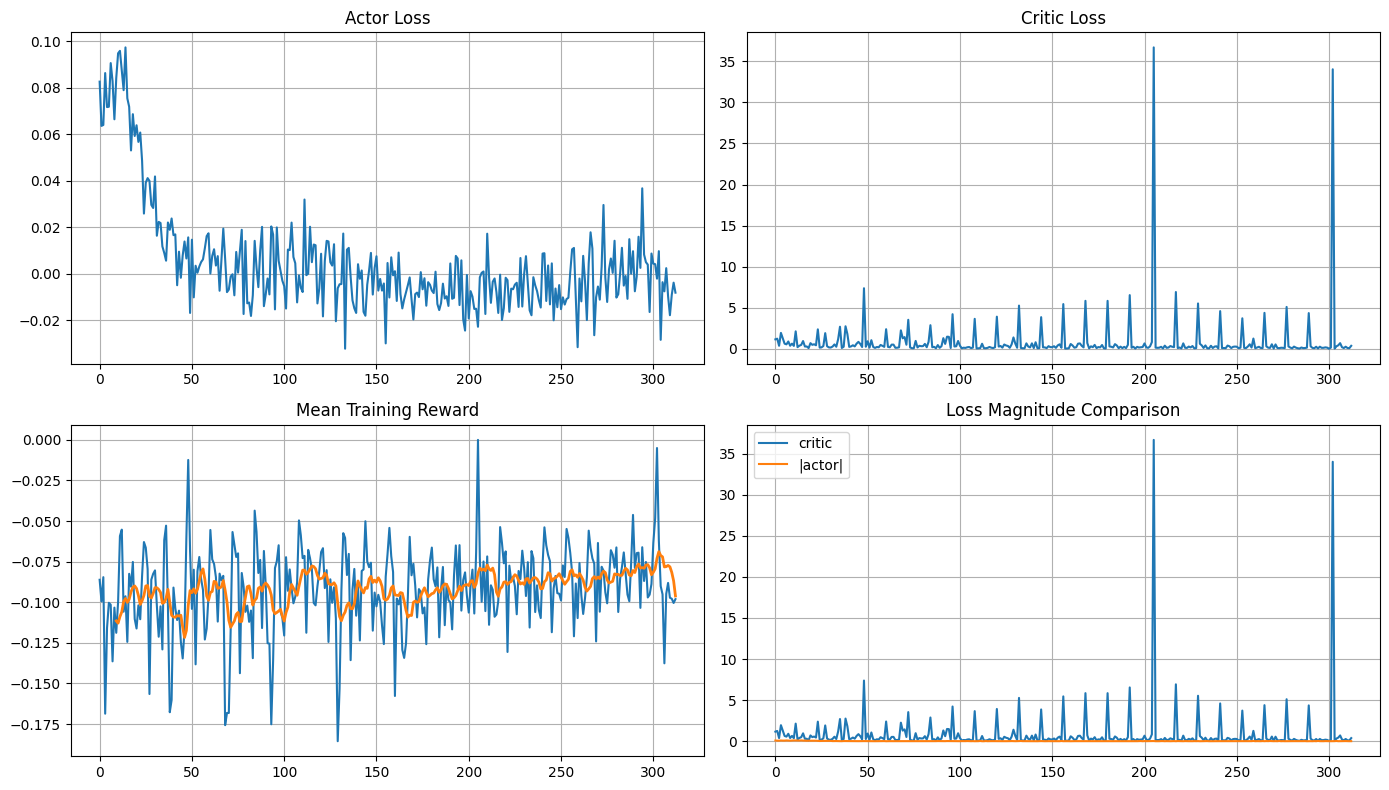

Final Actor Loss : -0.008198
Final Critic Loss: 0.377768
Best Critic Loss : 0.026951
Mean Reward      : -0.091673
Final Reward     : -0.098047


In [13]:
plot_training_history(map_gat_history)

In [ ]:
'''
SEARCH_SPACE = [
    # actor_lr, critic_lr, entropy_coef

    (1e-4, 3e-4, 0.03),
    (1e-4, 3e-4, 0.05),
    (1e-4, 3e-4, 0.07),

    (3e-4, 5e-4, 0.03),
    (3e-4, 5e-4, 0.05),
    (3e-4, 5e-4, 0.07),

    (5e-4, 1e-3, 0.03),
    (5e-4, 1e-3, 0.05),
    (5e-4, 1e-3, 0.07),
]

results = []

for run_id, (
    actor_lr,
    critic_lr,
    entropy_coef,
) in enumerate(
    SEARCH_SPACE,
    start=1,
):

    print(
        f"\n===== RUN {run_id}/{len(SEARCH_SPACE)} ====="
    )

    print(
        f"actor_lr={actor_lr} "
        f"critic_lr={critic_lr} "
        f"entropy_coef={entropy_coef}"
    )

    model, history, model_path = (
        train_graph_ctde(
            config_file=paths.config_file,
            network_file=paths.network_file,
            traffic_light_ids=traffic_light_ids,
            output_dir=OUTPUT_DIR,
            total_timesteps=20_000,
            rollout_steps=126,
            actor_learning_rate=actor_lr,
            critic_learning_rate=critic_lr,
            entropy_coef=entropy_coef,
            env_kwargs={
                "green_phase_count": GREEN_PHASE_COUNT,
                "min_green_seconds": MIN_GREEN_SECONDS,
                "seconds_per_action": SECONDS_PER_ACTION,
                "switch_penalty": SWITCH_PENALTY,
                "global_metric_interval": 10,
            },
        )
    )

    evaluation = evaluate_policy(
        model=model,
        config_file=paths.config_file,
        network_file=paths.network_file,
        traffic_light_ids=traffic_light_ids,
        episodes=3,
        max_steps=EPISODE_STEPS,
    )

    results.append({
        "actor_lr": actor_lr,
        "critic_lr": critic_lr,
        "entropy_coef": entropy_coef,
        "reward": evaluation["mean_total_reward"],
        "waiting_time": evaluation["mean_waiting_time"],
        "arrived": evaluation["mean_arrived_vehicles_per_episode"],
        "switches": evaluation["mean_switches_per_episode"],
    })

    df = pd.DataFrame(results)

    df = df.sort_values(
        "reward",
        ascending=False,
    )

    clear_output(wait=True)

    print(
        "\n===== CURRENT LEADERBOARD =====\n"
    )

    display(df)

    plt.figure(
        figsize=(12, 5)
    )

    labels = [
        (
            f"A={r['actor_lr']}\n"
            f"C={r['critic_lr']}\n"
            f"E={r['entropy_coef']}"
        )
        for r in results
    ]

    rewards = [
        r["reward"]
        for r in results
    ]

    plt.bar(
        range(len(rewards)),
        rewards,
    )

    plt.xticks(
        range(len(labels)),
        labels,
        rotation=45,
        ha="right",
    )

    plt.ylabel(
        "Mean Evaluation Reward"
    )

    plt.title(
        "Hyperparameter Search"
    )

    plt.tight_layout()

    plt.show()

df = pd.DataFrame(results)

df = df.sort_values(
    "reward",
    ascending=False,
)

print("\n===== FINAL RESULTS =====\n")

display(df)

df.to_csv(
    "hyperparameter_search_results.csv",
    index=False,
)

print(
    "\nSaved: hyperparameter_search_results.csv"
)'''

# Git stuff

In [20]:
!git status


On branch zak_new
Your branch is up to date with 'origin/zak_new'.

nothing to commit, working tree clean


In [15]:
!git add .

In [16]:
import shlex
commit_msg = '''
- Fixed g-mappo Critic Loss display bug.
- Reverted to vanilla critichead
'''

'''
TODO:
- Heterogenous networks
- Full Training run on bigger networks
- Possible integration with Andy's updated code
- Possible integration with Tom's networks
'''

"\nTODO:\n- Heterogenous networks\n- Full Training run on bigger networks\n- Possible integration with Andy's updated code\n- Possible integration with Tom's networks\n"

In [17]:
print(commit_msg)


- Fixed g-mappo Critic Loss display bug.
- Reverted to vanilla critichead



In [18]:
!git config --global user.email "zakfayle@gmail.com"
!git config --global user.name "IsaacFayle-Waters"
!git commit -m {shlex.quote(commit_msg)}

[zak_new 8b63afd] - Fixed g-mappo Critic Loss display bug. - Reverted to vanilla critichead
 2 files changed, 7 insertions(+), 10 deletions(-)


In [19]:
!git push origin zak_new

Enumerating objects: 15, done.
Counting objects: 100% (15/15), done.
Delta compression using up to 2 threads
Compressing objects: 100% (7/7), done.
Writing objects: 100% (8/8), 717 bytes | 717.00 KiB/s, done.
Total 8 (delta 6), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (6/6), completed with 6 local objects.
To https://github.com/abergh18/marl-tsc.git
   77543eb..8b63afd  zak_new -> zak_new
